# Lab | Transfer Learning & Fine-Tuning

This notebook follows the README tasks for the Oxford Flowers-102 transfer learning lab. It covers the from-scratch baseline, ResNet18 feature extraction, and fine-tuning the last residual block.

## Setup and imports

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(42)
print('device:', device)

device: cpu


## ImageNet preprocessing
Standard preprocessing is critical for pretrained models.

In [2]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize(232),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

val_tf = transforms.Compose([
    transforms.Resize(232),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

## Data loading
Load the Flowers-102 dataset using the canonical train/val/test splits and batch size 32.

In [3]:
batch_size = 32

train_dataset = datasets.Flowers102(root='data', split='train', download=True, transform=train_tf)
val_dataset = datasets.Flowers102(root='data', split='val', download=True, transform=val_tf)
test_dataset = datasets.Flowers102(root='data', split='test', download=True, transform=val_tf)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

len(train_dataset), len(val_dataset), len(test_dataset)

100%|██████████| 345M/345M [01:13<00:00, 4.67MB/s] 
100%|██████████| 502/502 [00:00<00:00, 720kB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 19.8MB/s]


(1020, 1020, 6149)

## Common utilities
Define helper functions for training, evaluation, plotting, and parameter counting.

In [4]:
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def count_total_params(model):
    return sum(p.numel() for p in model.parameters())

def evaluate(model, loader, criterion):
    model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss_sum += loss.item() * inputs.size(0)
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += inputs.size(0)
    return loss_sum / total, correct / total

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    start_time = time.time()
    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_total = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            _, preds = outputs.max(1)
            running_correct += (preds == labels).sum().item()
            running_total += inputs.size(0)
        train_loss = running_loss / running_total
        train_acc = running_correct / running_total
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        best_val_acc = max(best_val_acc, val_acc)
        scheduler.step()
        print(f'Epoch {epoch}/{num_epochs} - train_loss={train_loss:.4f} train_acc={train_acc:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}')
    total_time = time.time() - start_time
    print(f'Training complete in {total_time:.1f}s - best val acc={best_val_acc:.4f}')
    return history, best_val_acc, total_time

def plot_metrics(history, title='Metrics'):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='train_loss')
    plt.plot(history['val_loss'], label='val_loss')
    plt.legend()
    plt.title(title + ' loss')

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='train_acc')
    plt.plot(history['val_acc'], label='val_acc')
    plt.legend()
    plt.title(title + ' accuracy')
    plt.show()

## Task 1 — From-Scratch Baseline
Build a small CNN for 224×224 inputs and 102 outputs, train for 15 epochs, plot metrics, and record validation and test accuracy.

In [5]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=102):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model_scratch = SmallCNN(num_classes=102).to(device)
print('Trainable params:', count_trainable_params(model_scratch))
print('Total params:', count_total_params(model_scratch))

Trainable params: 51526758
Total params: 51526758


c:\Users\aysum\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/15 - train_loss=15.2517 train_acc=0.0069 val_loss=4.6099 val_acc=0.0108
Epoch 2/15 - train_loss=4.6172 train_acc=0.0108 val_loss=4.6232 val_acc=0.0137
Epoch 3/15 - train_loss=4.6097 train_acc=0.0157 val_loss=4.5932 val_acc=0.0147
Epoch 4/15 - train_loss=4.6011 train_acc=0.0147 val_loss=4.5885 val_acc=0.0186
Epoch 5/15 - train_loss=4.6234 train_acc=0.0108 val_loss=4.6028 val_acc=0.0147
Epoch 6/15 - train_loss=4.5937 train_acc=0.0127 val_loss=4.5398 val_acc=0.0196
Epoch 7/15 - train_loss=4.5862 train_acc=0.0157 val_loss=4.5553 val_acc=0.0176
Epoch 8/15 - train_loss=4.5958 train_acc=0.0137 val_loss=4.5300 val_acc=0.0196
Epoch 9/15 - train_loss=4.5762 train_acc=0.0147 val_loss=4.5093 val_acc=0.0196
Epoch 10/15 - train_loss=4.5547 train_acc=0.0157 val_loss=4.5154 val_acc=0.0196
Epoch 11/15 - train_loss=4.5453 train_acc=0.0147 val_loss=4.4977 val_acc=0.0206
Epoch 12/15 - train_loss=4.5474 train_acc=0.0186 val_loss=4.4997 val_acc=0.0196
Epoch 13/15 - train_loss=4.5487 train_acc=0.0157

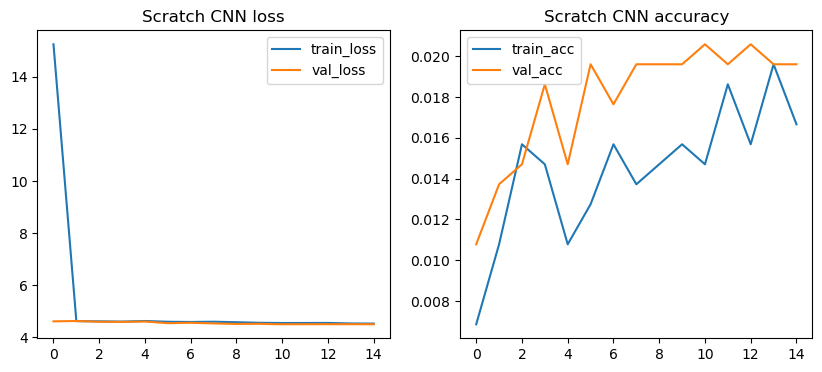

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer_scratch = optim.Adam(model_scratch.parameters(), lr=1e-3)
scheduler_scratch = optim.lr_scheduler.CosineAnnealingLR(optimizer_scratch, T_max=15)

history_scratch, best_val_acc_scratch, scratch_time = train_model(
    model_scratch, train_loader, val_loader, criterion, optimizer_scratch, scheduler_scratch, num_epochs=15
)
scratch_test_loss, scratch_test_acc = evaluate(model_scratch, test_loader, criterion)
print(f'Final test accuracy (from scratch): {scratch_test_acc:.4f}')
plot_metrics(history_scratch, title='Scratch CNN')

## Task 2 — Feature Extraction with ResNet18
Load pretrained ResNet18, freeze the backbone, replace `fc`, verify trainable parameters, and train for 15 epochs.

In [7]:
model_fe = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).to(device)
for p in model_fe.parameters():
    p.requires_grad = False
model_fe.fc = nn.Linear(model_fe.fc.in_features, 102).to(device)

trainable_params_fe = count_trainable_params(model_fe)
total_params_fe = count_total_params(model_fe)
print(f'Trainable params: {trainable_params_fe} / {total_params_fe}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\aysum/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:06<00:00, 7.56MB/s]


Trainable params: 52326 / 11228838


Epoch 1/15 - train_loss=4.6199 train_acc=0.0422 val_loss=3.8287 val_acc=0.1804
Epoch 2/15 - train_loss=3.3682 train_acc=0.3637 val_loss=2.9449 val_acc=0.4980
Epoch 3/15 - train_loss=2.4452 train_acc=0.6765 val_loss=2.2946 val_acc=0.6922
Epoch 4/15 - train_loss=1.8258 train_acc=0.8098 val_loss=1.8885 val_acc=0.7431
Epoch 5/15 - train_loss=1.4229 train_acc=0.8853 val_loss=1.5878 val_acc=0.7941
Epoch 6/15 - train_loss=1.1347 train_acc=0.9255 val_loss=1.4177 val_acc=0.8088
Epoch 7/15 - train_loss=0.9542 train_acc=0.9412 val_loss=1.3012 val_acc=0.8167
Epoch 8/15 - train_loss=0.8111 train_acc=0.9637 val_loss=1.2251 val_acc=0.8304
Epoch 9/15 - train_loss=0.7288 train_acc=0.9745 val_loss=1.1585 val_acc=0.8265
Epoch 10/15 - train_loss=0.6591 train_acc=0.9735 val_loss=1.1125 val_acc=0.8333
Epoch 11/15 - train_loss=0.6264 train_acc=0.9784 val_loss=1.0957 val_acc=0.8382
Epoch 12/15 - train_loss=0.5935 train_acc=0.9824 val_loss=1.0662 val_acc=0.8363
Epoch 13/15 - train_loss=0.5774 train_acc=0.9794 

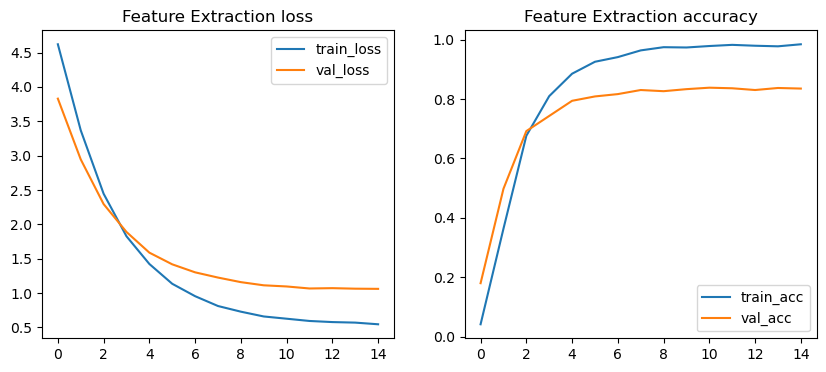

In [8]:
optimizer_fe = optim.Adam(filter(lambda p: p.requires_grad, model_fe.parameters()), lr=1e-3)
scheduler_fe = optim.lr_scheduler.CosineAnnealingLR(optimizer_fe, T_max=15)

history_fe, best_val_acc_fe, fe_time = train_model(
    model_fe, train_loader, val_loader, criterion, optimizer_fe, scheduler_fe, num_epochs=15
)
fe_test_loss, fe_test_acc = evaluate(model_fe, test_loader, criterion)
print(f'Final test accuracy (feature extraction): {fe_test_acc:.4f}')
plot_metrics(history_fe, title='Feature Extraction')

## Task 3 — Fine-Tune Last Block and Compare
Unfreeze `layer4` and `fc`, train with discriminative learning rates, and compare all three approaches.

In [9]:
for p in model_fe.layer4.parameters():
    p.requires_grad = True
for p in model_fe.fc.parameters():
    p.requires_grad = True

optimizer_ft = optim.Adam([
    {'params': model_fe.layer4.parameters(), 'lr': 1e-5},
    {'params': model_fe.fc.parameters(), 'lr': 1e-3},
])
scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=10)
print('Trainable params after unfreezing:', count_trainable_params(model_fe))

Trainable params after unfreezing: 8446054


Epoch 1/10 - train_loss=0.6482 train_acc=0.9441 val_loss=0.9318 val_acc=0.8294
Epoch 2/10 - train_loss=0.3782 train_acc=0.9755 val_loss=0.7668 val_acc=0.8500
Epoch 3/10 - train_loss=0.2721 train_acc=0.9863 val_loss=0.6990 val_acc=0.8539
Epoch 4/10 - train_loss=0.2064 train_acc=0.9971 val_loss=0.6456 val_acc=0.8696
Epoch 5/10 - train_loss=0.1668 train_acc=0.9951 val_loss=0.6153 val_acc=0.8735
Epoch 6/10 - train_loss=0.1388 train_acc=0.9990 val_loss=0.6004 val_acc=0.8706
Epoch 7/10 - train_loss=0.1191 train_acc=0.9980 val_loss=0.5866 val_acc=0.8706
Epoch 8/10 - train_loss=0.1156 train_acc=0.9980 val_loss=0.5749 val_acc=0.8706
Epoch 9/10 - train_loss=0.1092 train_acc=0.9980 val_loss=0.5636 val_acc=0.8765
Epoch 10/10 - train_loss=0.1145 train_acc=0.9971 val_loss=0.5724 val_acc=0.8706
Training complete in 947.2s - best val acc=0.8765
Final test accuracy (fine-tuned): 0.8618


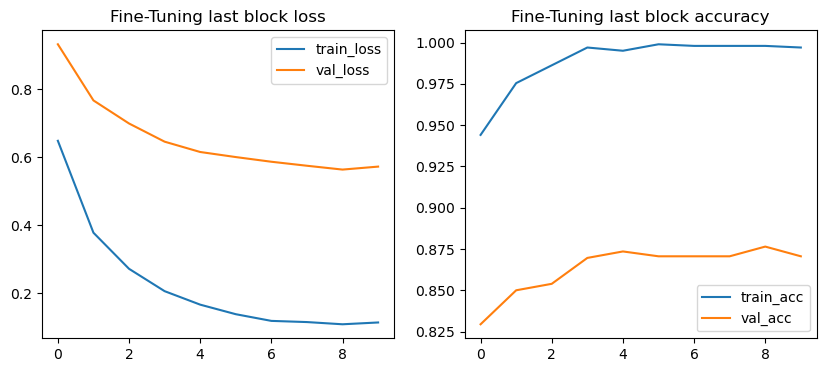

In [10]:
history_ft, best_val_acc_ft, ft_time = train_model(
    model_fe, train_loader, val_loader, criterion, optimizer_ft, scheduler_ft, num_epochs=10
)
ft_test_loss, ft_test_acc = evaluate(model_fe, test_loader, criterion)
print(f'Final test accuracy (fine-tuned): {ft_test_acc:.4f}')
plot_metrics(history_ft, title='Fine-Tuning last block')

## Comparison Table
Run the notebook cells and fill in or print the table below once metrics are available.

In [11]:
print('| Approach | Trainable params | Best val acc | Test acc | Total training time |')
print('|---|---|---|---|---|')
print(f'| From scratch (Task 1) | {count_trainable_params(model_scratch)} | {best_val_acc_scratch:.4f} | {scratch_test_acc:.4f} | {scratch_time:.1f}s |')
print(f'| Feature extraction (Task 2) | {trainable_params_fe} | {best_val_acc_fe:.4f} | {fe_test_acc:.4f} | {fe_time:.1f}s |')
print(f'| Fine-tune last block (Task 3) | {count_trainable_params(model_fe)} | {best_val_acc_ft:.4f} | {ft_test_acc:.4f} | {ft_time:.1f}s |')

| Approach | Trainable params | Best val acc | Test acc | Total training time |
|---|---|---|---|---|
| From scratch (Task 1) | 51526758 | 0.0206 | 0.0125 | 1451.9s |
| Feature extraction (Task 2) | 52326 | 0.8382 | 0.8205 | 1225.7s |
| Fine-tune last block (Task 3) | 8446054 | 0.8765 | 0.8618 | 947.2s |


## Summary
Write a 4–6 sentence summary here answering: how much did transfer learning improve over from-scratch, did fine-tuning the last block help over feature extraction, and which configuration would you recommend for the cat-detection assessment and why?

## Checklist
- [ ] From-scratch baseline trained with curves and final test accuracy.
- [ ] Feature-extraction model trained with curves; trainable param count printed.
- [ ] Fine-tuned model with discriminative learning rates trained.
- [ ] Comparison table completed and summary written.
- [ ] `Kernel → Restart & Run All` produces no errors.